# Nearest-Neighbor Validation (1-to-1 Matching)
For each real matrix, find the **single closest** artificial matrix in the feature space.
Then compare per-format GFLOPs to see how well the generator replicates performance
when given the most structurally similar synthetic counterpart.

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean as scipy_gmean
import subprocess, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
# Publication settings
width = 3.487
height = width / 1.618
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 7})

palette = ['#4daf4a','#e41a1c','#984ea3','#377eb8','#ff7f00']
ranges_dev = ['NVIDIA-H100', 'AMD-MI250', 'AMD-EPYC-64', 'INTEL-SAPPHIRE-56', 'ARM-GRACE-72']
# palette = ['#4daf4a', '#e41a1c', '#ffff33', '#984ea3', '#377eb8', '#ff7f00']
# ranges_dev = ['NVIDIA-H100', 'AMD-MI250', 'NVIDIA-RTX3060', 'AMD-EPYC-64', 'INTEL-SAPPHIRE-56', 'ARM-GRACE-72']
color_dictionary = dict(zip(ranges_dev, palette))

def change_colors(devs, cdict):
    sns.set_palette([v for k,v in cdict.items() if k in devs])

change_colors(ranges_dev, color_dictionary)

In [3]:
# Format name mapping (from benchmark_aggregation.ipynb)
format_name_mapping = {
    'cuSPARSE_csr11': 'cu-CSR', 'cuSPARSE_coo11': 'cu-COO', 'cuSPARSE_hyb9-2': 'cu-HYB',
    'CUSPARSE_CSR': 'cu-CSR', 'CUSPARSE_COO': 'cu-COO',
    'ROCSPARSE_CSR': 'roc-CSR', 'ROCSPARSE_COO': 'roc-COO', 'ROCSPARSE_HYB': 'roc-HYB',
    'Merge_11': 'Merge-CSR', 'MERGE_CUDA': 'Merge-CSR', 'MERGE': 'Merge-CSR',
    'Custom_CSR_CUDA_ADAPTIVE_b512_1': 'Ada-CSR', 'Custom_CSR_CUDA_ADAPTIVE_b256_1': 'Ada-CSR',
    'Custom_CSR_ROCM_ADAPTIVE_b512_1': 'Ada-CSR',
    'Custom_CSR_CUDA_VECTOR_b256': 'Vec-CSR', 'Custom_CSR_ROCM_VECTOR_b512': 'Vec-CSR',
    'Custom_CSR_CUDA_constant_nnz_per_thread_b1024_nnz4': 'Custom-CSR',
    'Custom_CSR_ROCM_constant_nnz_per_thread_b512_nnz4': 'Custom-CSR',
    'ACC_LINE_ENHANCE_b512': 'ACC-Line', 'ACC_FLAT_b512': 'ACC-Flat',
    'SELL-32-1': 'SELL-C-σ', 'Naive_CSR_CPU': 'Naive-CSR',
    'Custom_CSR_B': 'Bal-CSR', 'Custom_CSR_BV_x86': 'Vec-CSR', 'Custom_CSR_BV_SVE': 'Vec-CSR',
    'Custom_CSR_PBV': 'Custom_CSR_BV',
    'MKL_IE': 'MKL-IE', 'AOCL_OPTMV': 'AOCL', 'ARMPL': 'ARM-lib',
    'SparseX': 'SparseX', 'CSR5_9': 'CSR5', 'CSR5_CUDA': 'CSR5', 'CSR5': 'CSR5',
    'DASP_CUDA': 'DASP', 'LCM': 'LCM',
}

In [4]:
# Load data
df_real_all = pd.read_csv('validation_real_benchmarks_all-devices_all.csv')
df_friends_all = pd.read_csv('validation_friends_benchmarks_all-devices_all.csv')
print(f'Real: {df_real_all.shape}, Friends: {df_friends_all.shape}')

# Apply format mapping to real data
df_real_all['format_name'] = df_real_all['format_name'].replace(format_name_mapping)

# Filter devices & exclude matrices
exclude_matrices = ['mawi_201512012345', 'kmer_V2a']
df_real_all = df_real_all[df_real_all['System'].isin(ranges_dev) & ~df_real_all['matrix_name'].isin(exclude_matrices)]
df_friends_all = df_friends_all[df_friends_all['System'].isin(ranges_dev)]

# Dedup: if multiple raw names map to same short name for same (matrix, device, format), keep best
df_real_all = df_real_all.loc[df_real_all.groupby(['matrix_name','System','format_name'])['gflops'].idxmax()].reset_index(drop=True)
print(f'After filter+dedup => Real: {df_real_all.shape}, Friends: {df_friends_all.shape}')
print(f'Unique real matrices: {df_real_all["matrix_name"].nunique()}')

os.makedirs('./CSVs/', exist_ok=True)
os.makedirs('./Plots/1to1_analysis/', exist_ok=True)

Real: (4280, 32), Friends: (268041, 30)
After filter+dedup => Real: (2048, 32), Friends: (137210, 30)
Unique real matrices: 50


---
# Nearest-Neighbor Friend Matching
For each real matrix, find the **single closest** artificial matrix using Euclidean distance
on Z-score normalized features. Then expand that single match back to all its formats.

In [5]:
# Feature matching
llc_threshold = {'AMD-EPYC-64': 256, 'INTEL-SAPPHIRE-56': 105, 'ARM-GRACE-72': 114}
FEATURES = ['nr_rows', 'avg_nnz_per_row', 'skew', 'cross_row_similarity', 'avg_num_neighbours']

def find_nearest_friend(row, friends_device, system):
    """Hierarchical 3-stage matching to find the single closest artificial matrix.
    
    Stage 1: Structural filter -- avg_num_neighbours + cross_row_similarity (hard filter)
    Stage 2: Size/density match -- nr_rows + avg_nnz_per_row (Euclidean on Z-score)
    Stage 3: Skew tiebreaker -- log-scale distance on skew
    """
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    candidates = friends_device.drop_duplicates(subset=dedup_cols).copy()
    
    # ---- Stage 0: LLC filtering for CPUs (unchanged) ----
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            candidates = candidates[candidates['mem_footprint'] < llc_threshold[system]]
        else:
            candidates = candidates[candidates['mem_footprint'] > llc_threshold[system]]
    
    if candidates.empty:
        return pd.DataFrame(), None, 0
    
    # ---- Stage 1: Structural filter (avg_num_neighbours + cross_row_similarity) ----
    structural_features = ['avg_num_neighbours', 'cross_row_similarity']
    stage1_tolerance = 0.35  # +/-35% relative tolerance
    stage1_abs_fallback = 0.05  # absolute tolerance when real value is very small
    
    stage1_mask = pd.Series(True, index=candidates.index)
    for feat in structural_features:
        real_val = row[feat]
        if abs(real_val) < 0.1:
            # Absolute tolerance for near-zero values
            stage1_mask = stage1_mask & (candidates[feat] >= real_val - stage1_abs_fallback) & \
                                        (candidates[feat] <= real_val + stage1_abs_fallback)
        else:
            lo = real_val * (1 - stage1_tolerance)
            hi = real_val * (1 + stage1_tolerance)
            stage1_mask = stage1_mask & (candidates[feat] >= lo) & (candidates[feat] <= hi)
    
    survivors = candidates[stage1_mask]
    
    # Fallback: if Stage 1 eliminated everything, progressively widen tolerance
    widen_step = 0.10
    while survivors.empty and stage1_tolerance < 1.0:
        stage1_tolerance += widen_step
        stage1_mask = pd.Series(True, index=candidates.index)
        for feat in structural_features:
            real_val = row[feat]
            if abs(real_val) < 0.1:
                abs_tol = stage1_abs_fallback + (stage1_tolerance - 0.35) * 0.1
                stage1_mask = stage1_mask & (candidates[feat] >= real_val - abs_tol) & \
                                            (candidates[feat] <= real_val + abs_tol)
            else:
                lo = real_val * (1 - stage1_tolerance)
                hi = real_val * (1 + stage1_tolerance)
                stage1_mask = stage1_mask & (candidates[feat] >= lo) & (candidates[feat] <= hi)
        survivors = candidates[stage1_mask]
    
    # Last resort: if still empty, use all candidates
    if survivors.empty:
        survivors = candidates
    
    # ---- Stage 1b: nr_rows hard constraint ----
    # Prevent extreme nr_rows mismatches (>100% difference)
    # by preferring survivors within a reasonable nr_rows range.
    real_nr = row['nr_rows']
    nr_rows_mask = (survivors['nr_rows'] >= real_nr * 0.33) & (survivors['nr_rows'] <= real_nr * 3.0)
    nr_rows_filtered = survivors[nr_rows_mask]
    if not nr_rows_filtered.empty:
        survivors = nr_rows_filtered
    
    # ---- Stage 2: Size/density match (nr_rows + avg_nnz_per_row) ----
    # Use RELATIVE difference (not Z-score) to avoid distribution distortion.
    # This ensures a 20% nr_rows mismatch is always penalized equally,
    # regardless of how many survivors there are or their spread.
    real_nr_rows = max(row['nr_rows'], 1e-9)
    real_avg_nnz = max(row['avg_nnz_per_row'], 1e-9)
    
    rel_diff_nr_rows = np.abs(survivors['nr_rows'].values - real_nr_rows) / real_nr_rows
    rel_diff_avg_nnz = np.abs(survivors['avg_nnz_per_row'].values - real_avg_nnz) / real_avg_nnz
    
    # Equal weight: both features contribute proportionally
    size_distances = rel_diff_nr_rows + rel_diff_avg_nnz
    
    # ---- Stage 3: Skew tiebreaker (log-scale) ----
    real_skew = row['skew']
    friend_skews = survivors['skew'].values.astype(np.float64)
    
    # Log-scale distance: makes small skew differences irrelevant, large ones significant
    skew_distances = np.abs(np.log1p(np.abs(friend_skews)) - np.log1p(np.abs(real_skew)))
    
    # Normalize skew distances to [0, 1] range for fair weighting
    skew_max = skew_distances.max() + 1e-9
    skew_norm = skew_distances / skew_max
    
    # Normalize size distances to [0, 1] range
    size_max = size_distances.max() + 1e-9
    size_norm = size_distances / size_max
    
    # Combined score: size/density dominates, skew is a tiebreaker
    SKEW_WEIGHT = 0.25
    combined_score = size_norm + SKEW_WEIGHT * skew_norm
    
    # Pick the single best
    best_idx = np.argmin(combined_score)
    best_distance = combined_score[best_idx]
    
    closest_row = survivors.iloc[[best_idx]]
    closest_keys = closest_row[dedup_cols]
    
    # Expand: get ALL format rows for this single synthetic matrix
    matched_friends = friends_device.merge(closest_keys, on=dedup_cols, how='inner')
    return matched_friends, best_distance, len(survivors)

---
# Per-Format Error Computation (1-to-1)
For each (device, matrix, format), compare real GFLOPs vs the single closest friend's GFLOPs.
Since there is only one friend, the error is a simple APE (Absolute Percentage Error), not MAPE.

In [6]:
def compute_per_format_errors_1to1(ranges_dev, df_real_all, df_friends_all):
    """For each real matrix, find the single closest friend. Compare per-format GFLOPs."""
    all_results = []
    for system in ranges_dev:
        print(f'\n=== {system} ===')
        real_dev = df_real_all[df_real_all['System'] == system].sort_values('mem_footprint')
        friends_dev = df_friends_all[df_friends_all['System'] == system]
        real_matrices = real_dev['matrix_name'].unique()
        for mtx in real_matrices:
            real_mtx = real_dev[real_dev['matrix_name'] == mtx]
            row_ref = real_mtx.iloc[0]  # features are same across formats
            matched_friend, distance, n_survivors = find_nearest_friend(row_ref, friends_dev, system)
            if matched_friend.empty:
                continue
            # Per format
            real_formats = set(real_mtx['format_name'])
            friend_formats = set(matched_friend['format_name'])
            common_formats = real_formats & friend_formats
            for fmt in common_formats:
                real_gflops = real_mtx[real_mtx['format_name']==fmt]['gflops'].values[0]
                friend_gflops_vals = matched_friend[matched_friend['format_name']==fmt]['gflops'].values
                if real_gflops <= 0 or len(friend_gflops_vals) == 0:
                    continue
                # With 1-to-1 matching there should be exactly one value, but take best if duplicates exist
                friend_gflops = friend_gflops_vals[0]
                ape = abs(friend_gflops - real_gflops) / real_gflops * 100
                abs_error = abs(friend_gflops - real_gflops)
                signed_pct = (friend_gflops - real_gflops) / real_gflops * 100  # +ve = overpredict
                all_results.append({
                    'System': system, 'matrix_name': mtx, 'format_name': fmt,
                    'real_gflops': real_gflops, 'friend_gflops': friend_gflops,
                    'APE': ape, 'abs_error_gflops': abs_error, 'signed_pct': signed_pct,
                    'distance': distance, 'n_survivors': n_survivors,
                    'mem_footprint': row_ref['mem_footprint'],
                })
        print(f'  {len(real_matrices)} matrices processed')
    return pd.DataFrame(all_results)

In [7]:
results_df = compute_per_format_errors_1to1(ranges_dev, df_real_all, df_friends_all)
print(f'\nTotal results: {results_df.shape}')
results_df.head(10)


=== NVIDIA-H100 ===
  50 matrices processed

=== AMD-MI250 ===
  50 matrices processed

=== AMD-EPYC-64 ===
  50 matrices processed

=== INTEL-SAPPHIRE-56 ===
  50 matrices processed

=== ARM-GRACE-72 ===
  50 matrices processed

Total results: (1980, 11)


,System,matrix_name,format_name,real_gflops,friend_gflops,APE,abs_error_gflops,signed_pct,distance,n_survivors,mem_footprint
0,NVIDIA-H100,scircuit,Ada-CSR,142.52860,142.596070,0.047338,0.067470,0.047338,0.000588,202,11.6265
1,NVIDIA-H100,scircuit,DASP,43.73800,41.739263,4.569795,1.998737,-4.569795,0.000588,202,11.6265
2,NVIDIA-H100,scircuit,Vec-CSR,49.07304,49.098838,0.052570,0.025798,0.052570,0.000588,202,11.6265
3,NVIDIA-H100,scircuit,cu-COO,128.97400,125.096870,3.006133,3.877130,-3.006133,0.000588,202,11.6265
4,NVIDIA-H100,scircuit,cu-CSR,132.62740,126.661685,4.498102,5.965715,-4.498102,0.000588,202,11.6265
5,NVIDIA-H100,scircuit,Merge-CSR,85.42026,83.453780,2.302124,1.966480,-2.302124,0.000588,202,11.6265
6,NVIDIA-H100,scircuit,Custom-CSR,115.23620,108.487518,5.856390,6.748682,-5.856390,0.000588,202,11.6265
7,NVIDIA-H100,scircuit,CSR5,113.37260,110.293043,2.716315,3.079557,-2.716315,0.000588,202,11.6265
8,NVIDIA-H100,mac_econ_fwd500,DASP,127.60980,163.613824,28.214153,36.004024,28.214153,0.018342,70,15.3605
9,NVIDIA-H100,mac_econ_fwd500,Vec-CSR,55.79918,56.474279,1.209872,0.675099,1.209872,0.018342,70,15.3605


---
# GFLOPs Percentile Filtering
Drop (matrix, format) pairs where `real_gflops` falls below the Nth percentile on that device.
These are format/matrix combinations where the format is unsuitable for the matrix structure.

In [8]:
# Filter out low-performing (matrix, format) pairs
# Keep only entries where real_gflops >= Nth percentile on that device
# GFLOPS_PERCENTILE_THRESHOLD = 12.5
# GFLOPS_PERCENTILE_THRESHOLD = 7.5
# GFLOPS_PERCENTILE_THRESHOLD = 5
GFLOPS_PERCENTILE_THRESHOLD = 0

before = len(results_df)
print('\n=== GFLOPs Filtering Summary ===')
for dev in ranges_dev:
    dev_mask = results_df['System'] == dev
    p_val = np.percentile(results_df.loc[dev_mask, 'real_gflops'], GFLOPS_PERCENTILE_THRESHOLD)
    drop_count = (dev_mask & (results_df['real_gflops'] < p_val)).sum()
    dev_total = dev_mask.sum()
    drop_mask = dev_mask & (results_df['real_gflops'] < p_val)
    results_df = results_df[~drop_mask]
    print(f"  {dev:18s} | cutoff: {p_val:6.2f} GFLOPs | Dropped: {drop_count:3d} / {dev_total:3d} entries")

results_df = results_df.reset_index(drop=True)
print(f"\nFiltered: {before} -> {len(results_df)} entries")


=== GFLOPs Filtering Summary ===
  NVIDIA-H100        | cutoff:   1.84 GFLOPs | Dropped:   0 / 389 entries
  AMD-MI250          | cutoff:   0.88 GFLOPs | Dropped:   0 / 400 entries
  AMD-EPYC-64        | cutoff:   0.62 GFLOPs | Dropped:   0 / 476 entries
  INTEL-SAPPHIRE-56  | cutoff:   1.27 GFLOPs | Dropped:   0 / 418 entries
  ARM-GRACE-72       | cutoff:   6.48 GFLOPs | Dropped:   0 / 297 entries

Filtered: 1980 -> 1980 entries


---
# Summary Tables

In [9]:
# Table 1: Per-device, per-format APE summary (with spread & bias)
fmt_summary = results_df.groupby(['System','format_name']).agg(
    APE_median=('APE','median'), APE_mean=('APE','mean'), APE_std=('APE','std'),
    APE_CV=('APE', lambda x: (x.std() / x.mean() * 100) if x.mean() > 0 else 0),
    AbsErr_median=('abs_error_gflops','median'),
    Bias_mean=('signed_pct','mean'),  # positive = generator overpredicts
    n_matrices=('matrix_name','nunique')
).reset_index()
fmt_summary = fmt_summary.round(2)

for dev in ranges_dev:
    print(f'\n=== {dev} ===')
    dev_df = fmt_summary[fmt_summary['System']==dev].sort_values('APE_median', ascending=False)
    print(dev_df.to_string(index=False))

fmt_summary.to_csv('./CSVs/validation_1to1_per_format_summary.csv', index=False)
print('\nSaved: ./CSVs/validation_1to1_per_format_summary.csv')


=== NVIDIA-H100 ===
     System format_name  APE_median  APE_mean  APE_std  APE_CV  AbsErr_median  Bias_mean  n_matrices
NVIDIA-H100        DASP        7.95     13.16    13.49  102.49          17.13      -1.32          50
NVIDIA-H100     Ada-CSR        6.37      8.25     9.40  114.04          11.29       4.31          39
NVIDIA-H100        CSR5        4.47      6.68     6.76  101.17          10.33       0.11          50
NVIDIA-H100  Custom-CSR        3.68     18.80    55.43  294.80           8.79       8.79          50
NVIDIA-H100     Vec-CSR        3.65      6.35     8.36  131.67           6.35       4.38          50
NVIDIA-H100      cu-COO        2.63      4.96     5.88  118.47           7.30      -2.50          50
NVIDIA-H100   Merge-CSR        2.56      4.05     3.92   96.83           5.59      -1.31          50
NVIDIA-H100      cu-CSR        2.37      7.19    19.29  268.34           7.87      -0.09          50

=== AMD-MI250 ===
   System format_name  APE_median  APE_mean  APE_st

In [10]:
# Table 2: Per-device condensed summary
dev_summary = results_df.groupby('System').agg(
    APE_median=('APE','median'),
    APE_gmean=('APE',scipy_gmean),
    APE_mean=('APE','mean'),
    APE_std=('APE','std'),
    # APE_CV=('APE', lambda x: (x.std() / x.mean() * 100) if x.mean() > 0 else 0),
    # AbsErr_median=('abs_error_gflops','median'),
    # Bias_mean=('signed_pct','mean'),
    # n_format_matrix_pairs=('matrix_name','count')
).reindex(ranges_dev).reset_index()
dev_summary.loc[len(dev_summary)] = ['Average'] + list(dev_summary.iloc[:,1:].mean())
dev_summary = dev_summary.round(2)
print('\n=== Per-Device Summary (1-to-1 Matching) ===')
print(f'For GFLOPS_PERCENTILE_THRESHOLD = {GFLOPS_PERCENTILE_THRESHOLD}') 
print(dev_summary.to_string(index=False))

dev_summary.to_csv('./CSVs/validation_1to1_per_device_summary.csv', index=False)
print('Saved: ./CSVs/validation_1to1_per_device_summary.csv')


=== Per-Device Summary (1-to-1 Matching) ===
For GFLOPS_PERCENTILE_THRESHOLD = 0
           System  APE_median  APE_gmean  APE_mean  APE_std
      NVIDIA-H100        3.77       3.43      8.69    22.57
        AMD-MI250        5.95       5.26     20.34    34.66
      AMD-EPYC-64       10.69       9.91     30.62   129.76
INTEL-SAPPHIRE-56       10.31       8.72     18.64    20.62
     ARM-GRACE-72       12.20       9.36     19.27    20.00
          Average        8.58       7.34     19.51    45.52
Saved: ./CSVs/validation_1to1_per_device_summary.csv


---
# Per-Device Matrix × Format Error Tables
Rows = matrices (sorted by mem_footprint), Columns = formats, Cells = APE (%)


  NVIDIA-H100 — APE (%) per Matrix × Format (1-to-1)
  -> Saved to ./CSVs/validation_1to1_APE_NVIDIA-H100.csv
  -> Saved to ./CSVs/validation_1to1_GFLOPS_NVIDIA-H100.csv


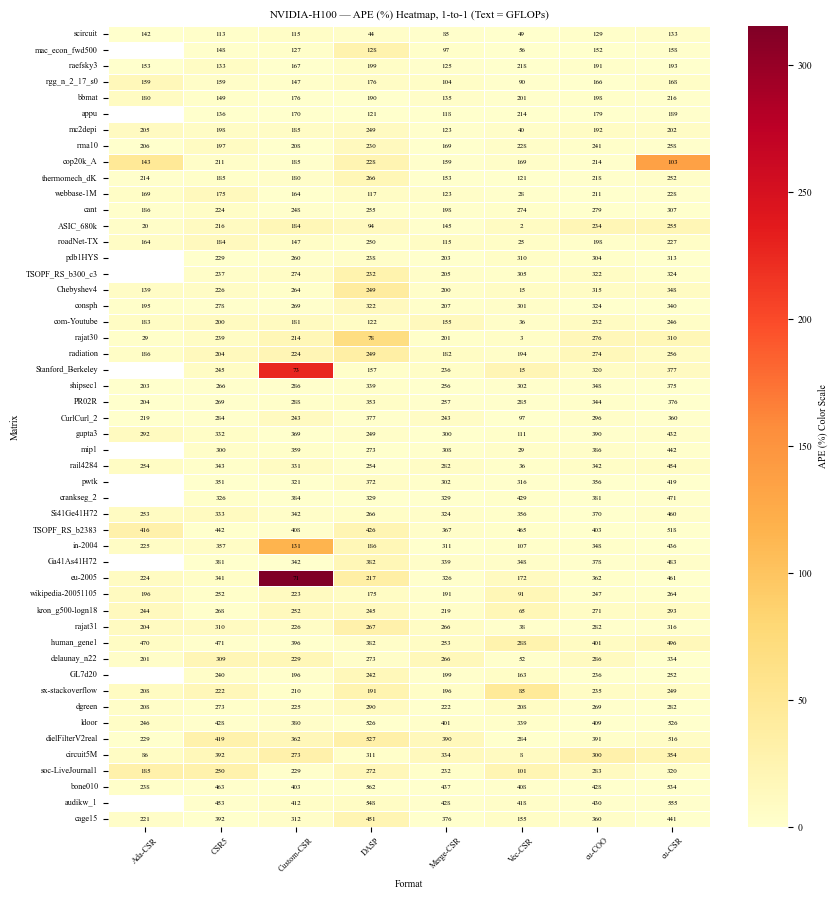


  AMD-MI250 — APE (%) per Matrix × Format (1-to-1)
  -> Saved to ./CSVs/validation_1to1_APE_AMD-MI250.csv
  -> Saved to ./CSVs/validation_1to1_GFLOPS_AMD-MI250.csv


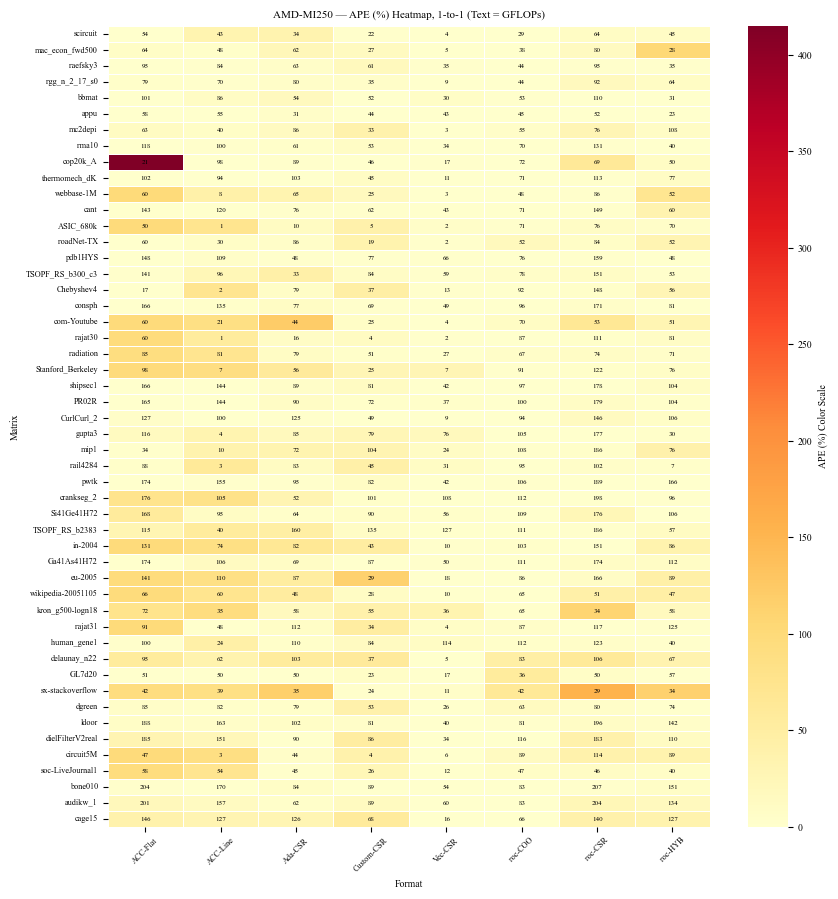


  AMD-EPYC-64 — APE (%) per Matrix × Format (1-to-1)
  -> Saved to ./CSVs/validation_1to1_APE_AMD-EPYC-64.csv
  -> Saved to ./CSVs/validation_1to1_GFLOPS_AMD-EPYC-64.csv


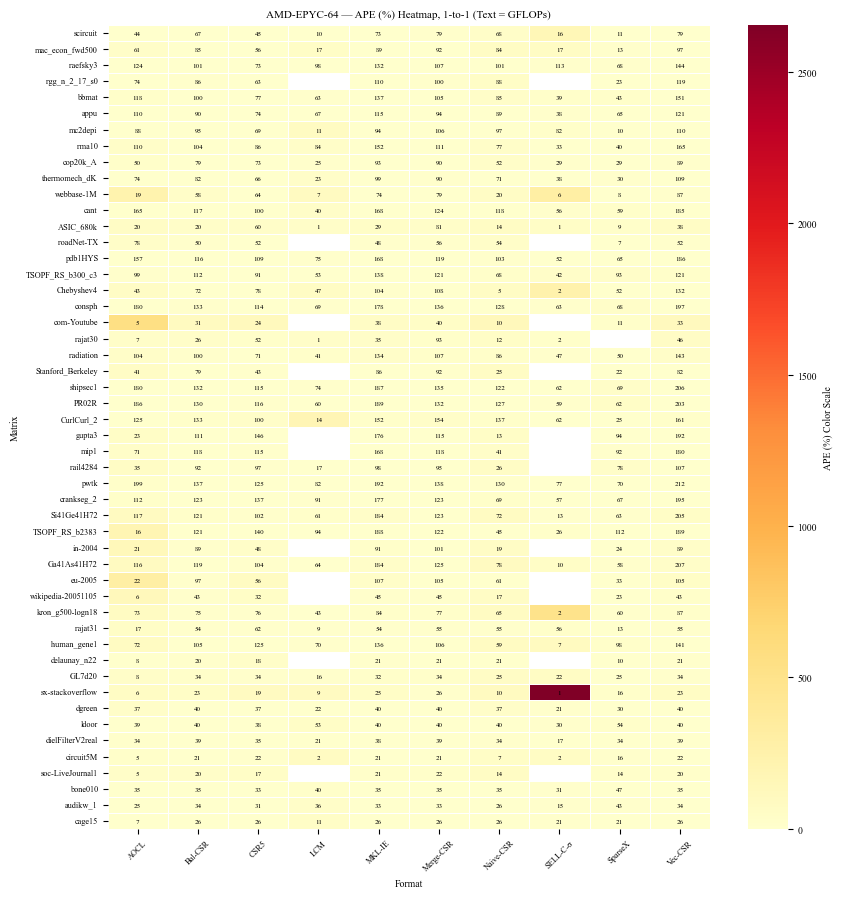


  INTEL-SAPPHIRE-56 — APE (%) per Matrix × Format (1-to-1)
  -> Saved to ./CSVs/validation_1to1_APE_INTEL-SAPPHIRE-56.csv
  -> Saved to ./CSVs/validation_1to1_GFLOPS_INTEL-SAPPHIRE-56.csv


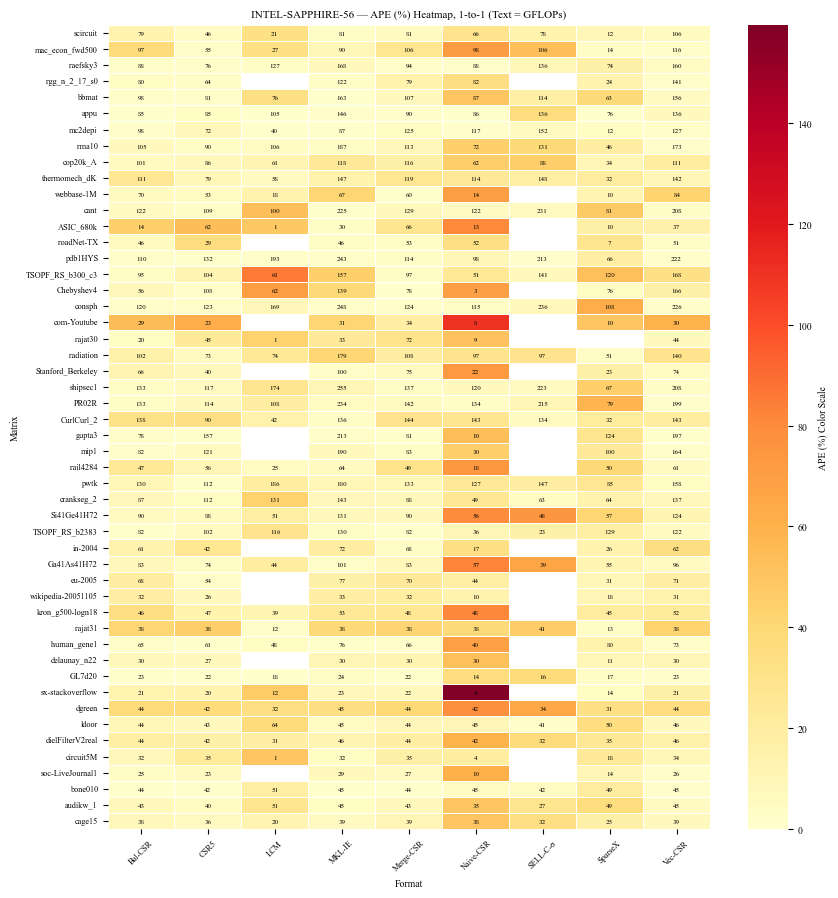


  ARM-GRACE-72 — APE (%) per Matrix × Format (1-to-1)
  -> Saved to ./CSVs/validation_1to1_APE_ARM-GRACE-72.csv
  -> Saved to ./CSVs/validation_1to1_GFLOPS_ARM-GRACE-72.csv


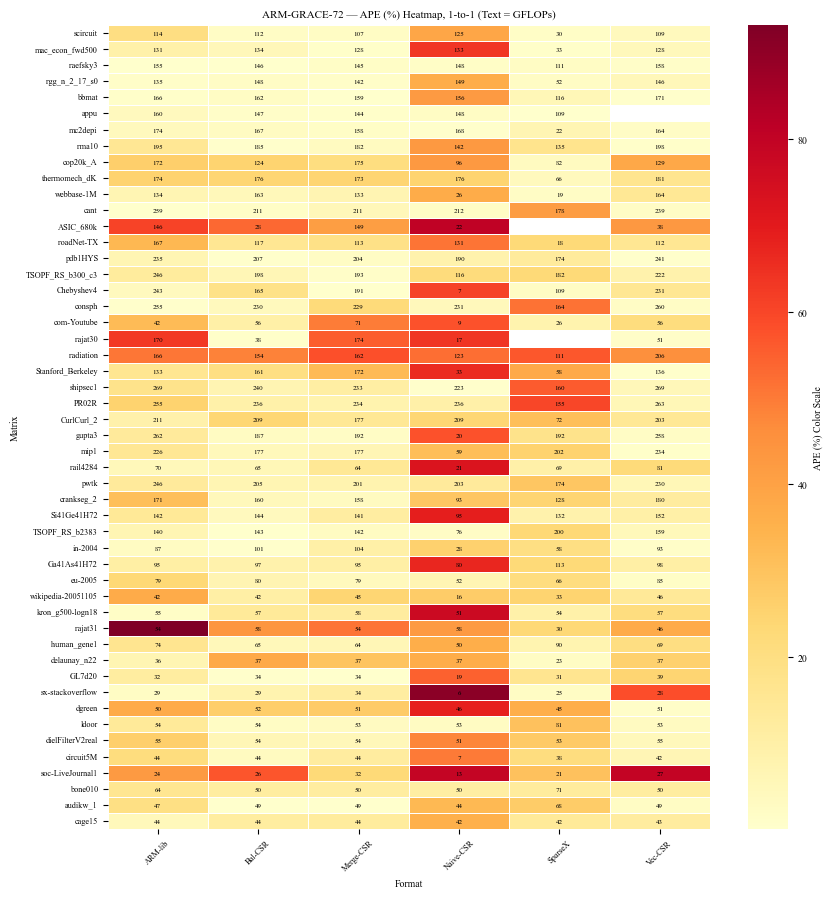

In [11]:
# Build pivot tables per device
for dev in ranges_dev:
    dev_results = results_df[results_df['System'] == dev].copy()
    if dev_results.empty:
        continue
    mtx_order = dev_results.drop_duplicates('matrix_name').sort_values('mem_footprint')['matrix_name'].values
    
    # APE Pivot
    pivot = dev_results.pivot_table(index='matrix_name', columns='format_name', values='APE', aggfunc='first')
    pivot = pivot.reindex(mtx_order)
    pivot['ROW_MEDIAN'] = pivot.median(axis=1)
    col_median = pivot.median(axis=0)
    col_median.name = 'COL_MEDIAN'
    pivot = pd.concat([pivot, col_median.to_frame().T])
    pivot = pivot.round(1)
    print(f'\n{"="*80}')
    print(f'  {dev} — APE (%) per Matrix × Format (1-to-1)')
    print(f'{"="*80}')
    # print(pivot.to_string())
    csv_name = f'./CSVs/validation_1to1_APE_{dev}.csv'
    pivot.to_csv(csv_name)
    print(f'  -> Saved to {csv_name}')
    
    # GFLOPs Pivot
    pivot_gflops = dev_results.pivot_table(index='matrix_name', columns='format_name', values='real_gflops', aggfunc='first')
    pivot_gflops = pivot_gflops.reindex(mtx_order)
    pivot_gflops = pivot_gflops.round(1)
    gflops_csv = f'./CSVs/validation_1to1_GFLOPS_{dev}.csv'
    pivot_gflops.to_csv(gflops_csv)
    print(f'  -> Saved to {gflops_csv}')
    
    # Heatmap: APE colored, GFLOPs annotated
    plot_pivot = pivot.drop('COL_MEDIAN', errors='ignore').drop(columns=['ROW_MEDIAN'], errors='ignore')
    annot_labels = pivot_gflops.reindex(plot_pivot.index).reindex(columns=plot_pivot.columns)
    annot_labels = annot_labels.apply(lambda col: col.map(lambda x: f"{x:.1f}" if pd.notna(x) else ""))
    
    fig, ax = plt.subplots(figsize=(width*2.5, len(plot_pivot)*0.15 + 1.5))

    sns.heatmap(plot_pivot, annot=False, cmap='YlOrRd', ax=ax, linewidths=0.5, cbar_kws={'label': 'APE (%) Color Scale'})
    
    for i in range(len(plot_pivot.index)):
        for j in range(len(plot_pivot.columns)):
            # Get the raw GFLOPs value
            val = pivot_gflops.iloc[i, j]
            
            # Format text label (leave blank if NaN)
            text = f"{val:.0f}" if pd.notna(val) else ""
            
            # Place text at coordinate (j + 0.5, i + 0.5) to center it in the cell
            # clip_on=True: Prevents rendering outside the bounding box
            ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=5, color='black', clip_on=True)

    ax.set_title(f'{dev} — APE (%) Heatmap, 1-to-1 (Text = GFLOPs)', fontsize=8)
    ax.set_xlabel('Format', fontsize=7)
    ax.set_ylabel('Matrix', fontsize=7)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6, rotation=0)
    plt.tight_layout()
    hm_name = f'./Plots/Validation_1to1_APE_heatmap_{dev}.pdf'
    fig.savefig(hm_name, bbox_inches='tight')
    plt.show()
    plt.close()

---
# Plotting: Stacked All-Devices Plot (1-to-1 Comparison)
One subplot per device. For each matrix: black dot = real GFLOPs, colored dot = closest friend GFLOPs.
Best-of format is used (highest GFLOPs format for the real matrix).

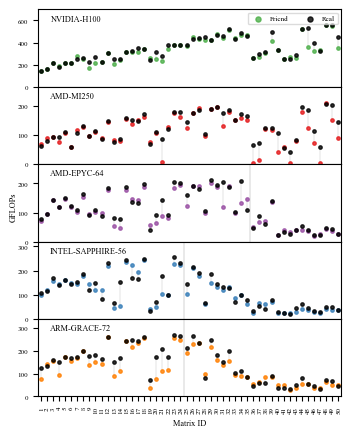

In [12]:
def plot_stacked_1to1(ranges_dev, df_real_all, df_friends_all, results_df):
    """Stacked dot plot: one subplot per device, real vs closest friend (best-of format)."""
    font = 7
    fig, axs = plt.subplots(len(ranges_dev))
    fig.subplots_adjust(left=.12, bottom=.17*(2/5)*(4/3.5), right=.99, top=.94)
    for ctr, system in enumerate(ranges_dev):
        change_colors([system], color_dictionary)
        
        # Get best-format per matrix (real)
        real_dev = df_real_all[df_real_all['System']==system].sort_values('mem_footprint')
        best_real = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()].sort_values('mem_footprint')
        matrix_names = best_real['matrix_name'].values
        
        # For each matrix, get the friend's GFLOPs for the same best format
        friend_gflops_list = []
        for _, row in best_real.iterrows():
            mtx = row['matrix_name']
            fmt = row['format_name']
            match = results_df[(results_df['System']==system) & 
                               (results_df['matrix_name']==mtx) & 
                               (results_df['format_name']==fmt)]
            if not match.empty:
                friend_gflops_list.append(match.iloc[0]['friend_gflops'])
            else:
                # Fallback: find best available format from results
                match_any = results_df[(results_df['System']==system) & 
                                       (results_df['matrix_name']==mtx)]
                if not match_any.empty:
                    friend_gflops_list.append(match_any.loc[match_any['friend_gflops'].idxmax()]['friend_gflops'])
                else:
                    friend_gflops_list.append(np.nan)
        
        x_pos = np.arange(len(matrix_names))

        # offset = 0.15
        offset = 0.0
        # Plot friend dots (colored, slightly offset left)
        axs[ctr].scatter(x_pos - offset, friend_gflops_list, 
                         color=color_dictionary[system], s=6, alpha=0.8, zorder=3, label='Friend')
        # Plot real dots (black, slightly offset right)
        axs[ctr].scatter(x_pos + offset, best_real['gflops'].values, 
                         color='k', s=6, alpha=0.8, zorder=3, label='Real')
        
        # Connect pairs with thin lines
        for xi, (fg, rg) in enumerate(zip(friend_gflops_list, best_real['gflops'].values)):
            if not np.isnan(fg):
                axs[ctr].plot([xi-offset, xi+offset], [fg, rg], 
                              color='gray', linewidth=0.3, alpha=0.5, zorder=2)
        
        # LLC threshold line for CPUs
        if 'Arch' in best_real.columns:
            arch = best_real['Arch'].iloc[0]
        else:
            arch = ''
        if arch == 'CPU' and system in llc_threshold:
            for mi, mtx in enumerate(matrix_names):
                me = best_real[best_real['matrix_name']==mtx]
                if me.empty: continue
                me = me.squeeze()
                mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
                if mf > llc_threshold[system]:
                    axs[ctr].axvline(x=mi - 0.5, color='gray', linewidth=0.25)
                    break
        
        axs[ctr].tick_params(axis='both', which='major', labelsize=font-2)
        axs[ctr].margins(x=0.01)
        axs[ctr].set_ylabel('')
        if ctr == len(ranges_dev)-1:
            xtick_labels = range(1, len(matrix_names)+1)
            axs[ctr].set_xlabel('Matrix ID', fontsize=font-1)
            axs[ctr].set_xticks(x_pos)
            axs[ctr].set_xticklabels(xtick_labels, fontsize=font-2, rotation=90)
        else:
            axs[ctr].set_xlabel('')
            axs[ctr].set_xticks([])
            axs[ctr].set_xticklabels([])
        axs[ctr].set_ylim([0, axs[ctr].get_ylim()[1]*1.2])
        axs[ctr].text(0.04, 0.85, system, fontsize=font-1, transform=axs[ctr].transAxes)
        if ctr == 0:
            axs[ctr].legend(fontsize=font-2, loc='upper right', ncol=2, 
                            markerscale=1.5, framealpha=0.7)
    fig.text(0.04, 0.5, 'GFLOPs', va='center', rotation='vertical', fontsize=font-1)
    plt.subplots_adjust(wspace=0, hspace=0)
    # for ratio in [0.8, 1, 1.2]:
    for ratio in [1]:
        fig.set_size_inches(width, 1.5*height/(2/5)*ratio*len(ranges_dev)/9)
        fname = f'./Plots/{ratio}_{len(ranges_dev)}_devices_Validation_1to1_stacked.pdf'
        fig.savefig(fname, bbox_inches='tight')
        subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        cropped = fname.replace('.pdf','-crop.pdf')
        if os.path.exists(cropped):
            subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()

plot_stacked_1to1(ranges_dev, df_real_all, df_friends_all, results_df)

---
# Per-Device Separate Plots (1-to-1)
One plot per device showing real vs friend GFLOPs for the best-of format per matrix.

In [13]:
def plot_single_device_1to1(system, df_real_all, results_df):
    """One plot per device: real (black dot) vs friend (colored dot) for best-of format."""
    font = 8
    change_colors([system], color_dictionary)
    
    # Get best-format per matrix (real)
    real_dev = df_real_all[df_real_all['System']==system].sort_values('mem_footprint')
    best_real = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()].sort_values('mem_footprint')
    matrix_names = best_real['matrix_name'].values
    
    # Get friend GFLOPs for same best format
    friend_gflops_list = []
    for _, row in best_real.iterrows():
        mtx = row['matrix_name']
        fmt = row['format_name']
        match = results_df[(results_df['System']==system) & 
                           (results_df['matrix_name']==mtx) & 
                           (results_df['format_name']==fmt)]
        if not match.empty:
            friend_gflops_list.append(match.iloc[0]['friend_gflops'])
        else:
            match_any = results_df[(results_df['System']==system) & 
                                   (results_df['matrix_name']==mtx)]
            if not match_any.empty:
                friend_gflops_list.append(match_any.loc[match_any['friend_gflops'].idxmax()]['friend_gflops'])
            else:
                friend_gflops_list.append(np.nan)
    
    x_pos = np.arange(len(matrix_names))
    
    fig, ax = plt.subplots(1, 1, figsize=(width*2, height*1.2))
    
    # Friend dots (colored, offset left)
    ax.scatter(x_pos - 0.15, friend_gflops_list, 
               color=color_dictionary[system], s=10, alpha=0.85, zorder=3, label='Friend')
    # Real dots (black, offset right)
    ax.scatter(x_pos + 0.15, best_real['gflops'].values, 
               color='k', s=10, alpha=0.85, zorder=3, label='Real')
    
    # Connect pairs with thin lines
    for xi, (fg, rg) in enumerate(zip(friend_gflops_list, best_real['gflops'].values)):
        if not np.isnan(fg):
            ax.plot([xi-0.15, xi+0.15], [fg, rg], 
                    color='gray', linewidth=0.4, alpha=0.5, zorder=2)
    
    # LLC threshold line for CPUs
    if 'Arch' in best_real.columns:
        arch = best_real['Arch'].iloc[0]
    else:
        arch = ''
    if arch == 'CPU' and system in llc_threshold:
        for mi, mtx in enumerate(matrix_names):
            me = best_real[best_real['matrix_name']==mtx]
            if me.empty: continue
            me = me.squeeze()
            mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
            if mf > llc_threshold[system]:
                ax.axvline(x=mi - 0.5, color='gray', linewidth=0.5, linestyle='--')
                break
    
    ax.set_title(system, fontsize=font)
    ax.set_xlabel('Matrix', fontsize=font-1)
    ax.set_ylabel('GFLOPs', fontsize=font-1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(matrix_names, fontsize=font-2, rotation=90)
    ax.tick_params(axis='y', labelsize=font-2)
    ax.set_ylim([0, ax.get_ylim()[1]*1.15])
    ax.legend(fontsize=font-2, loc='upper right', ncol=2, markerscale=1.5, framealpha=0.7)
    plt.tight_layout()
    os.makedirs('./Plots/1to1_analysis/', exist_ok=True)
    fname = f'./Plots/1to1_analysis/Validation_1to1_{system}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cropped = fname.replace('.pdf','-crop.pdf')
    if os.path.exists(cropped):
        subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()

In [14]:
# for dev in ranges_dev:
#     plot_single_device_1to1(dev, df_real_all, results_df)

---
# Overall Summary

In [15]:
# Print overall summary
print('\n' + '='*60)
print('OVERALL SUMMARY (1-to-1 Nearest Neighbor)')
print(f'For GFLOPS_PERCENTILE_THRESHOLD = {GFLOPS_PERCENTILE_THRESHOLD}')
print('='*60)
print(f'Overall Median APE:  {results_df["APE"].median():.2f}%')
print(f'Overall Mean APE:    {results_df["APE"].mean():.2f}%')
print(f'Overall Std APE:     {results_df["APE"].std():.2f}%')
print(f'Overall Median Abs Error: {results_df["abs_error_gflops"].median():.2f} GFLOPs')
print(f'Overall Mean Bias:   {results_df["signed_pct"].mean():+.2f}% (positive = overprediction)')
print()
print('Per-device breakdown:')
for dev in ranges_dev:
    d = results_df[results_df['System']==dev]
    bias = d['signed_pct'].mean()
    abs_err = d['abs_error_gflops'].median()
    print(f'  {dev:25s}  MedAPE={d["APE"].median():6.2f}%  MeanAPE={d["APE"].mean():6.2f}%  MedAbsErr={abs_err:5.2f} GFLOPs  Bias={bias:+6.2f}%')


OVERALL SUMMARY (1-to-1 Nearest Neighbor)
For GFLOPS_PERCENTILE_THRESHOLD = 0
Overall Median APE:  7.68%
Overall Mean APE:    20.00%
Overall Std APE:     67.72%
Overall Median Abs Error: 6.67 GFLOPs
Overall Mean Bias:   -0.66% (positive = overprediction)

Per-device breakdown:
  NVIDIA-H100                MedAPE=  3.77%  MeanAPE=  8.69%  MedAbsErr= 8.78 GFLOPs  Bias= +1.47%
  AMD-MI250                  MedAPE=  5.95%  MeanAPE= 20.34%  MedAbsErr= 3.80 GFLOPs  Bias= -4.44%
  AMD-EPYC-64                MedAPE= 10.69%  MeanAPE= 30.62%  MedAbsErr= 6.29 GFLOPs  Bias= +9.74%
  INTEL-SAPPHIRE-56          MedAPE= 10.31%  MeanAPE= 18.64%  MedAbsErr= 6.22 GFLOPs  Bias= -6.08%
  ARM-GRACE-72               MedAPE= 12.20%  MeanAPE= 19.27%  MedAbsErr= 9.65 GFLOPs  Bias= -7.37%


---
# Matched Friend Feature Comparison
Show, for each matrix, how closely the features of the closest friend match the real matrix.

In [16]:
# Build a feature comparison table for each device
for dev in ranges_dev:
    print(f'\n=== {dev} ===')
    real_dev = df_real_all[df_real_all['System'] == dev].sort_values('mem_footprint')
    friends_dev = df_friends_all[df_friends_all['System'] == dev]
    real_matrices = real_dev['matrix_name'].unique()
    comparison_rows = []
    for mtx in real_matrices:
        real_mtx = real_dev[real_dev['matrix_name'] == mtx]
        row_ref = real_mtx.iloc[0]
        matched_friends, best_distance, n_survivors = find_nearest_friend(row_ref, friends_dev, dev)
        if matched_friends.empty:
            continue
        friend_ref = matched_friends.iloc[0]
        row_data = {'matrix_name': mtx, 'distance': round(best_distance, 4), 'n_stage1_survivors': n_survivors}
        for feat in FEATURES:
            real_val = row_ref[feat]
            friend_val = friend_ref[feat]
            pct_diff = abs(real_val - friend_val) / max(abs(real_val), 1e-9) * 100
            row_data[f'{feat}_real'] = round(real_val, 2)
            row_data[f'{feat}_friend'] = round(friend_val, 2)
            row_data[f'{feat}_d%'] = round(pct_diff, 1)
        comparison_rows.append(row_data)
    comp_df = pd.DataFrame(comparison_rows)
    comp_df.to_csv(f'./CSVs/validation_1to1_feature_comparison_{dev}.csv', index=False)
    print(f'  -> Saved to ./CSVs/validation_1to1_feature_comparison_{dev}.csv')
    
    # ---- Clean APE-per-feature pivot (matrix x feature) ----
    ape_cols = {feat: f'{feat}_d%' for feat in FEATURES}
    ape_df = comp_df[['matrix_name'] + list(ape_cols.values())].copy()
    ape_df.columns = ['matrix_name'] + FEATURES
    ape_df['ROW_MEDIAN'] = ape_df[FEATURES].median(axis=1)
    col_med = ape_df[FEATURES + ['ROW_MEDIAN']].median()
    col_med['matrix_name'] = 'COL_MEDIAN'
    ape_df = pd.concat([ape_df, col_med.to_frame().T], ignore_index=True)
    ape_df[FEATURES + ['ROW_MEDIAN']] = ape_df[FEATURES + ['ROW_MEDIAN']].round(1)
    
    ape_csv = f'./CSVs/validation_1to1_feature_APE_{dev}.csv'
    ape_df.to_csv(ape_csv, index=False)
    print(f'  -> Saved to {ape_csv}')
    print(ape_df.to_string(index=False))
    
    # Per-feature summary
    print(f'\n  [Feature APE Summary for {dev}]')
    for feat in FEATURES:
        vals = comp_df[f'{feat}_d%']
        print(f'    {feat:30s}  median={vals.median():5.1f}%  mean={vals.mean():5.1f}%  max={vals.max():5.1f}%')


=== NVIDIA-H100 ===
  -> Saved to ./CSVs/validation_1to1_feature_comparison_NVIDIA-H100.csv
  -> Saved to ./CSVs/validation_1to1_feature_APE_NVIDIA-H100.csv
       matrix_name nr_rows avg_nnz_per_row   skew cross_row_similarity avg_num_neighbours ROW_MEDIAN
          scircuit     0.0             0.1    1.5                  3.7               24.2        1.5
   mac_econ_fwd500     0.0             0.1    2.6                  4.1                4.1        2.6
          raefsky3     0.0             0.1   72.4                  3.7                7.9        3.7
     rgg_n_2_17_s0     0.0             0.0   41.5                 44.7               45.1       41.5
             bbmat     0.0             2.0   12.1                  7.3                4.0        4.0
              appu     0.0             0.4   14.8                 66.0               98.4       14.8
           mc2depi     0.0             0.1  100.0                  0.8               24.9        0.8
             rma10     0.0        